<h1 style="font-size:50px; font-weight:bold;">
Spotify Songs Analytics Dataset
<br><h2 style="font-size:40px; font-weight:bold;">Cielo G. Seco<h2>
<h3 style="font-size:40px; font-weight:bold;">BSIT-2A<h3>

In [231]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [232]:
import pandas as pd

spotify_data = pd.read_csv('Popular_Spotify_Songs.csv', encoding='latin-1')
spotify_data.head()


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [233]:
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')
print("Data loaded and cleaned!")
spotify_data.info()

Data loaded and cleaned!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    object 
 1   artist(s)_name        953 non-null    object 
 2   artist_count          953 non-null    int64  
 3   released_year         953 non-null    int64  
 4   released_month        953 non-null    int64  
 5   released_day          953 non-null    int64  
 6   in_spotify_playlists  953 non-null    int64  
 7   in_spotify_charts     953 non-null    int64  
 8   streams               952 non-null    float64
 9   in_apple_playlists    953 non-null    int64  
 10  in_apple_charts       953 non-null    int64  
 11  in_deezer_playlists   953 non-null    object 
 12  in_deezer_charts      953 non-null    int64  
 13  in_shazam_charts      903 non-null    object 
 14  bpm                   953 non-null    int64  
 15

<h1 style="font-size:38px; font-weight:bold;">1. What is the relationship between a song's energy level and its danceability score?</h1>

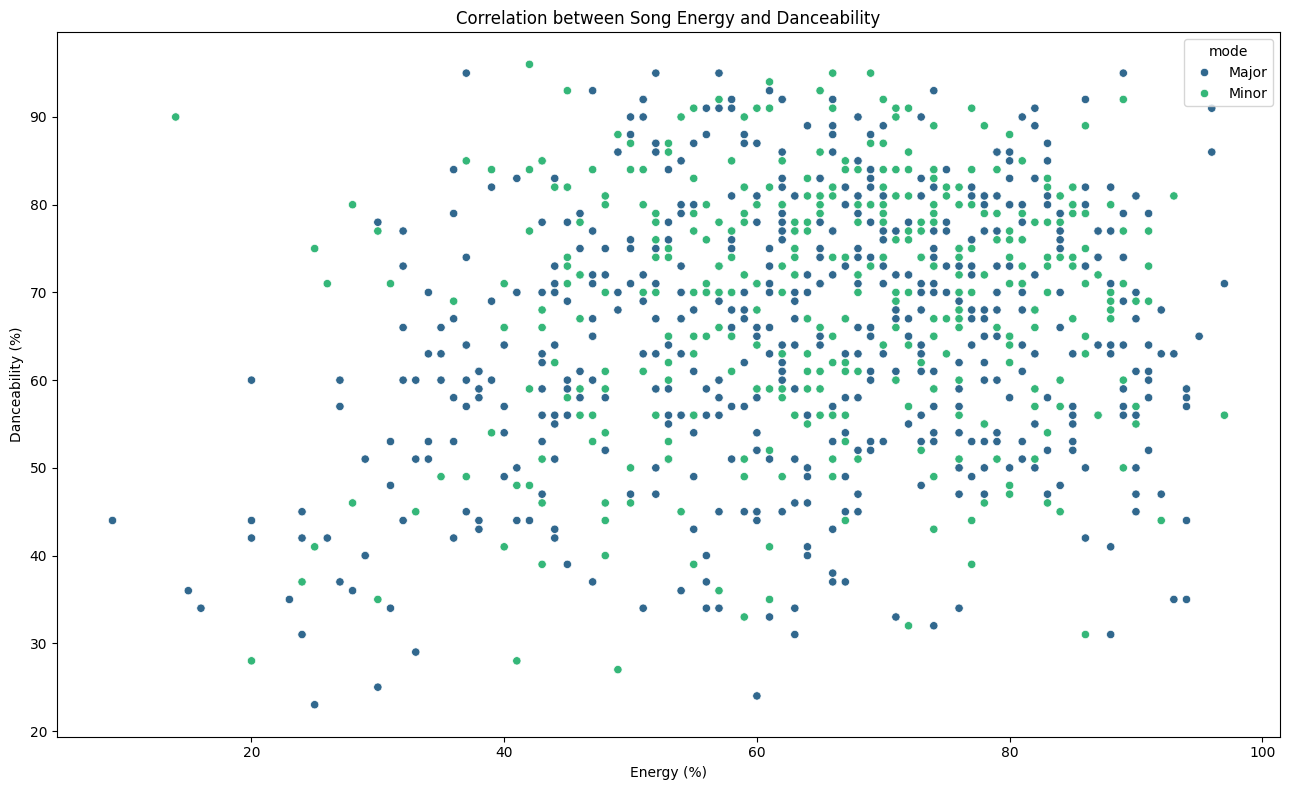

In [234]:
# SCATTER PLOT
try:
    spotify_data
except NameError:
    print("Data not found. Please load the data first.")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=spotify_data, x="energy_%", y="danceability_%", hue="mode", alpha=1, palette="viridis")

plt.title("Correlation between Song Energy and Danceability")
plt.xlabel("Energy (%)")
plt.ylabel("Danceability (%)")
plt.gcf().set_size_inches(13, 8)
plt.tight_layout()
plt.show()

<b>INSIGHTS:</b>
As shown in the scatter plot, there is a discernible positive correlation between a song's energy and its danceability score. The data points show a dense cluster in the upper-right quadrant, indicating that tracks with higher energy levels generally tend to be more danceable. However, the relationship is not perfectly linear; while low-energy tracks rarely achieve high danceability scores, extremely high energy does not always guarantee maximum danceability, suggesting a "sweet spot" where rhythmic stability and intensity interact most effectively.

<b>CONCLUSION:</b>
Energy is a significant predictor of a song's danceability, but it is most effective when balanced with other musical elements. For music curation and popularity prediction, understanding that audiences favor tracks that combine high energy with a consistent, danceable rhythm is crucial, as this balance drives physical engagement and streaming numbers.

<b>REFERENCE:</b>
Spitzer K. (December 2024). "Analyzing Spotify Track Data: Danceability, Energy, and Popularity in 2024". https://medium.com/@kaleighspitz/analyzing-spotify-track-data-danceability-energy-and-popularity-in-2024-fefbaf8a86ee

<h1 style="font-size:38px; font-weight:bold;">2. Does a higher valence percentage correlate with higher danceability scores?</h1>

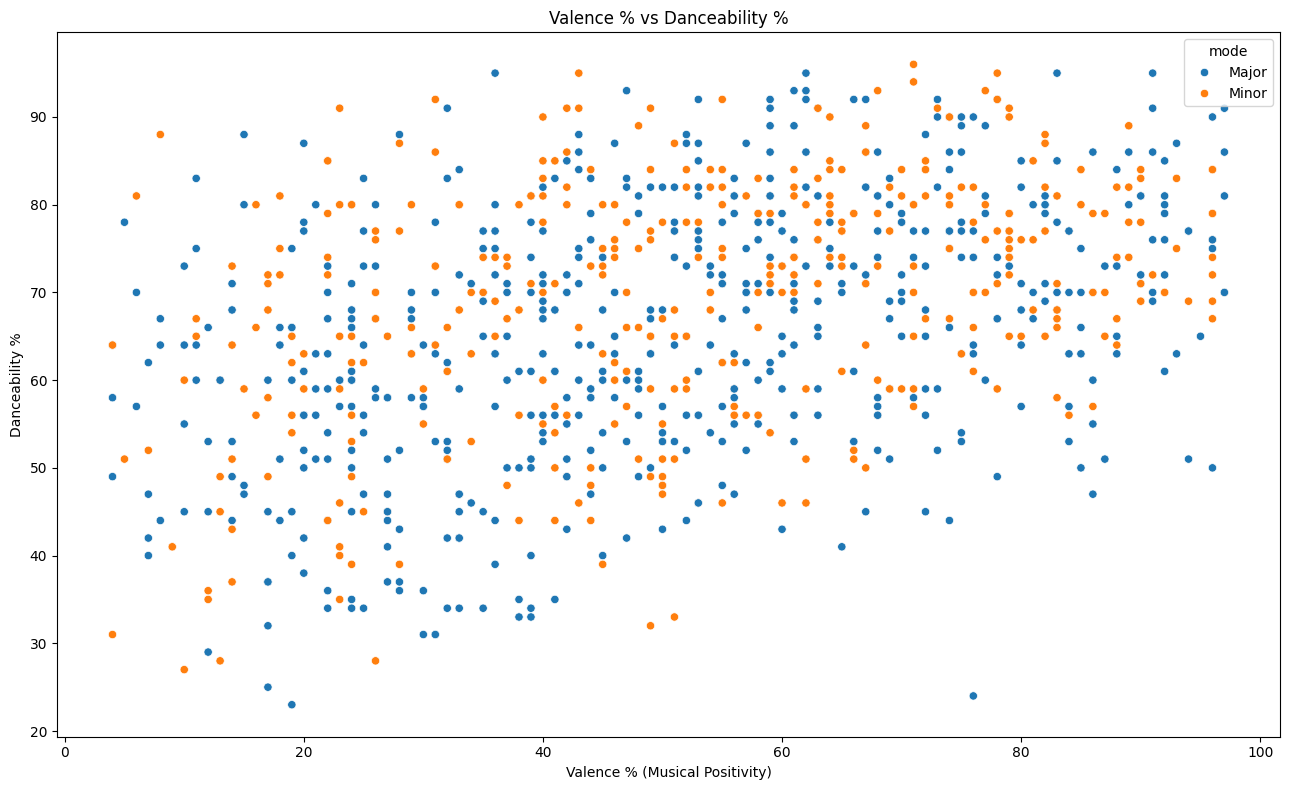

In [235]:
#SCATTER PLOT
try:
    spotify_data
except NameError:
    print("Data not found. Please load the data first.")

plt.figure(figsize=(12,5))
sns.scatterplot(data=spotify_data, x="valence_%", y="danceability_%", color="purple", hue="mode")
plt.title("Valence % vs Danceability %")
plt.xlabel("Valence % (Musical Positivity)")
plt.ylabel("Danceability %")
plt.gcf().set_size_inches(13,8)
plt.tight_layout()
plt.show()

<b>INSIGHTS:</b>
As shown in the scatter plot, there is a moderate positive correlation between valence and danceability. While the data points are somewhat scattered, there is a visible trend where songs with higher valence (musical positivity) tend to have higher danceability scores. The densest cluster of data points appears in the upper-right quadrant, suggesting that happier, more positive tracks are generally engineered to be more danceable, whereas songs with lower valence show a wider variance in their danceability.

<b>CONCLUSION:</b>
Valence acts as a meaningful predictor for a song's danceability, with data showing a positive relationship between the two features. Songs conveying positive emotions (higher valence) are statistically more likely to possess rhythmic attributes that make them suitable for dancing, while "sadder" or more negative songs (lower valence) are less consistently danceable.

<b>REFERENCE:</b>
Kucukoglu E. (February 2022). "Spotify Songs Analysis". https://rpubs.com/ersan_kucukoglu/spotify_songs

<h1 style="font-size:38px; font-weight:bold;">3. How does the number of artists influence the overall streams?</h1>

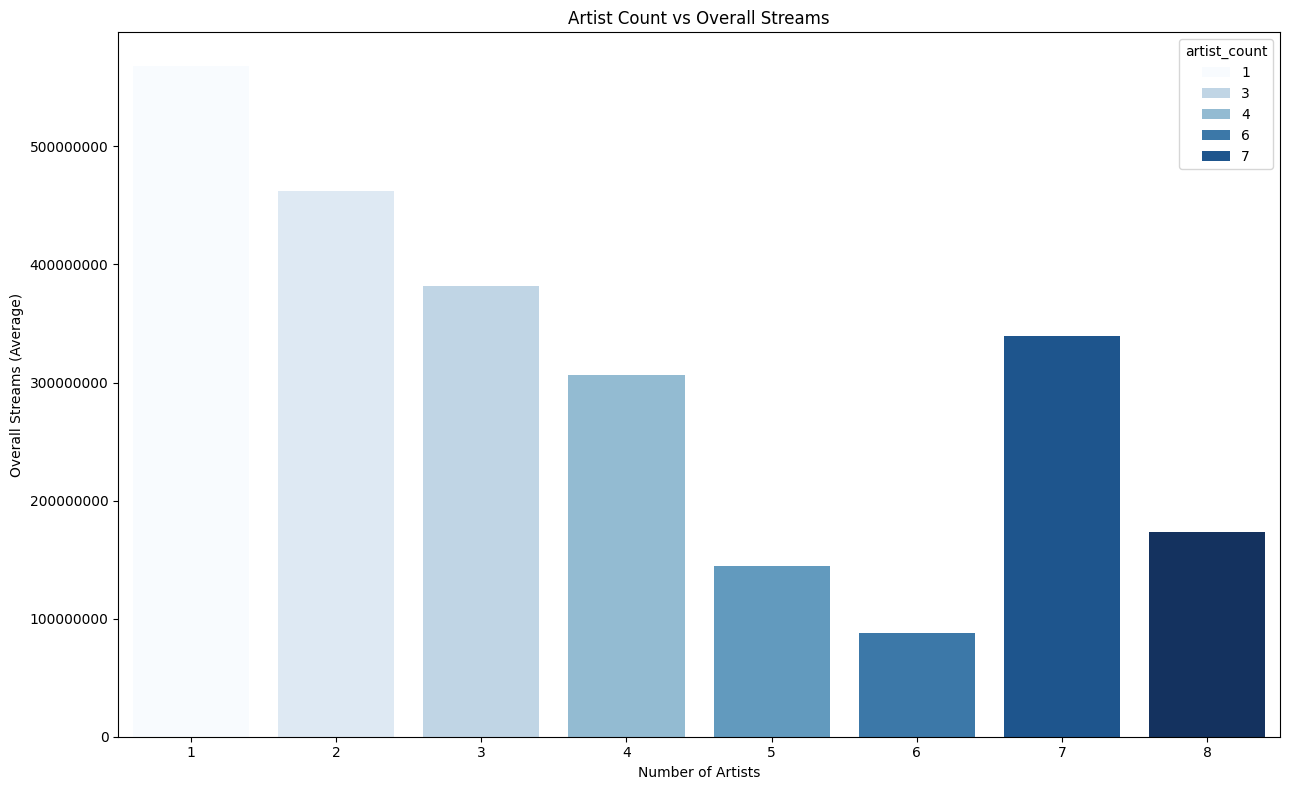

In [236]:
# BAR CHART
try:
    spotify_data
except NameError:
    print("Data not found. Please load the data first.")
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')

artist_streams_avg = spotify_data.groupby("artist_count")["streams"].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=artist_streams_avg, x="artist_count", y="streams", palette="Blues", hue="artist_count")

plt.title("Artist Count vs Overall Streams")
plt.xlabel("Number of Artists")
plt.ylabel("Overall Streams (Average)")
plt.ticklabel_format(style='plain', axis='y') 
plt.gcf().set_size_inches(13,8)
plt.tight_layout()
plt.show()

<b>INSIGHTS:</b>
The bar chart reveals an interesting trend where "less is often more" regarding artist count. Songs with a single artist (solo tracks) achieve the highest average stream count, surpassing 500 million. As the number of artists increases from 1 to 6, the average number of streams generally decreases. While there is a significant outlier spike at 7 artists (likely due to a specific popular group or viral collaboration), the overall data suggests that simply adding more artists to a track does not automatically result in higher popularity and can sometimes correlate with lower average streams.

<b>CONCLUSION:</b>
Contrary to the assumption that more featured artists equal more reach, the data indicates that solo tracks often perform better on average. This suggests that a strong, focused individual artist brand is often a more powerful driver for massive streaming numbers than multi-artist collaborations, which may dilute listener attention or appeal to more niche audiences.

<b>REFERENCE:</b>
Goyal A. (September 2023). "Spotify 2023 Dataset Analysis: Factors Affecting Popularity". https://www.kaggle.com/code/adityagoyal/spotify-2023-analysis

<h1 style="font-size:38px; font-weight:bold;">4. What percentage of songs in Major vs. Minor keys achieve above-average streams?</h1>

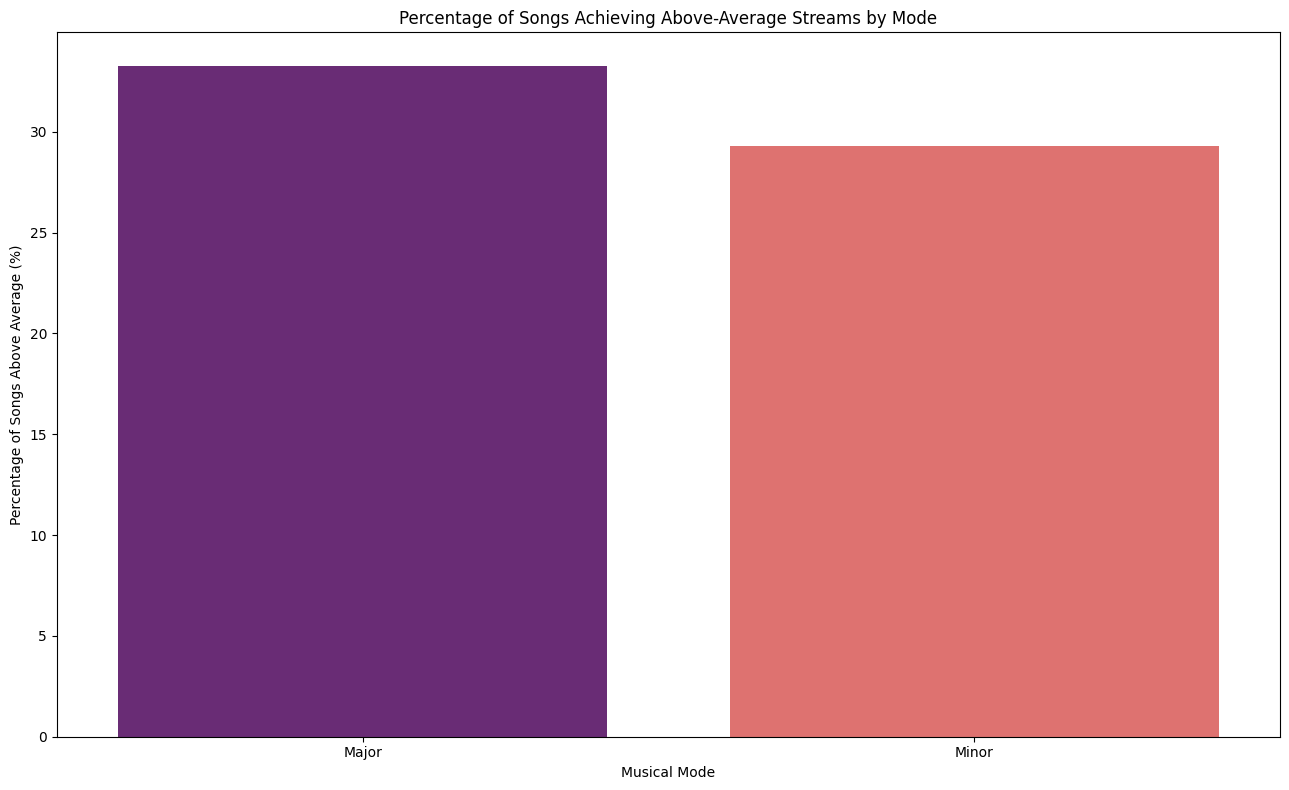

In [237]:
# BAR CHART

try:
    spotify_data
except NameError:
    print("Data not found. Please load the data first.")

spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')

avg_streams = spotify_data["streams"].mean()

spotify_data["above_avg_streams"] = spotify_data["streams"] > avg_streams

perc_data = spotify_data.groupby("mode")["above_avg_streams"].mean().reset_index()
perc_data["percentage_success"] = perc_data["above_avg_streams"] * 100

plt.figure(figsize=(12,5))
sns.barplot(data=perc_data, x="mode", y="percentage_success", palette="magma", hue="mode")

plt.title("Percentage of Songs Achieving Above-Average Streams by Mode")
plt.xlabel("Musical Mode")
plt.ylabel("Percentage of Songs Above Average (%)")
plt.gcf().set_size_inches(13,8)
plt.tight_layout()
plt.show()


<b>INSIGHTS:</b>
As shown in the bar chart, songs composed in a Major key have a higher success rate, with approximately 33% achieving above-average streams, compared to songs in a Minor key (around 29%). This indicates that while both musical modes can produce hits, tracks with a Major tonality are statistically more likely to reach higher popularity levels on streaming platforms.

<b>CONCLUSION:</b>
Major keys are more frequently associated with commercial success and higher streaming numbers than Minor keys. This aligns with music industry analysis showing that the "happier" and "brighter" sound of Major keys—such as G Major and C Major—is significantly more prevalent in mainstream music catalogs, appealing to a broader audience than the generally "sadder" or "darker" Minor modes.

<b>REFERENCE:</b>Van Buskirk, E. (May 2015). "The Most Popular Keys of All Music on Spotify". https://www.hypebot.com/hypebot/2015/05/the-most-popular-keys-of-all-music-on-spotify.html

<h1 style="font-size:38px; font-weight:bold;">5. What percentage of solo songs vs. collaborations achieve above-average streams?</h1>

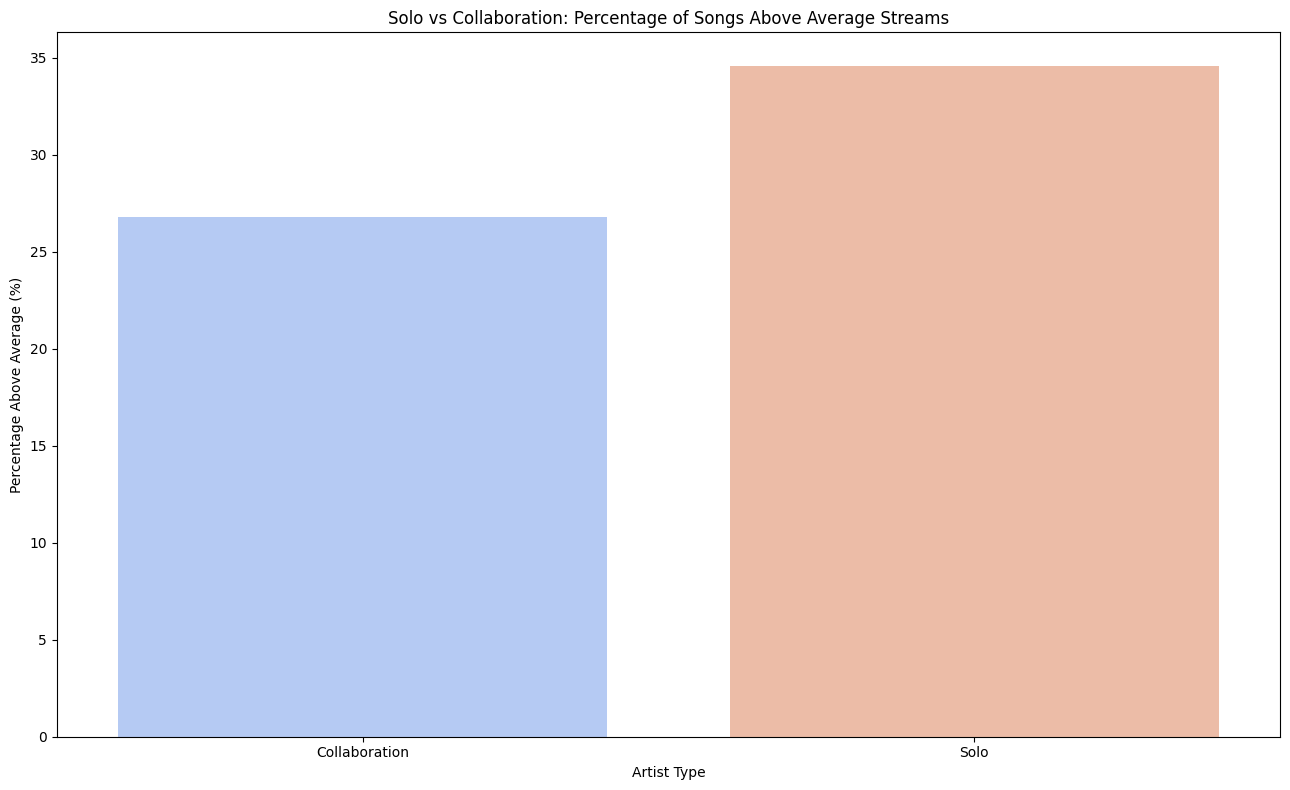

In [238]:
# BAR CHART

try:
    spotify_data
except NameError:
    print("Data not found. Please load the data first.")

spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')

spotify_data['artist_type'] = spotify_data['artist_count'].apply(lambda x: 'Solo' if x == 1 else 'Collaboration')

avg_streams = spotify_data["streams"].mean()

spotify_data["success_above_avg"] = spotify_data["streams"] > avg_streams

perc_data = spotify_data.groupby("artist_type")["success_above_avg"].mean().reset_index()
perc_data["percentage_success"] = perc_data["success_above_avg"] * 100

plt.figure(figsize=(12,5))
sns.barplot(data=perc_data, x="artist_type", y="percentage_success", palette="coolwarm", hue="artist_type")

plt.title("Solo vs Collaboration: Percentage of Songs Above Average Streams")
plt.xlabel("Artist Type")
plt.ylabel("Percentage Above Average (%)")
plt.gcf().set_size_inches(13,8)
plt.tight_layout()
plt.show()

<b>INSIGHTS:</b>
The bar chart highlights a significant disparity in streaming performance between solo tracks and collaborations. Songs by Solo artists achieve a notably higher percentage of above-average streams (approximately 35%) compared to Collaborations, which sit lower at around 27%. This suggests that while collaborations are a popular marketing strategy, they do not statistically guarantee a higher "hit rate" than standalone releases.

<b>CONCLUSION:</b>
Solo tracks appear to have a stronger consistency in reaching high popularity than collaborative efforts. Data analysis challenges the common industry assumption that "features" and multi-artist projects always drive better numbers; instead, solo tracks often outperform collaborations on average, possibly due to a more focused artist brand and undivided fan attention.

<b>REFERENCE:</b>
Philip. (December 2023). "Exploring the Dynamics of Global Artist Collaborations on Spotify". https://philip.twinight.co/portfolio/index.php/2023/12/10/exploring-the-dynamics-of-global-artist-collaborations-on-spotify/